# 🛠️ Travail à réaliser

## Partie 1 — Préparation et exploration des données

- Charger et explorer le dataset.
- Identifier les principales caractéristiques des données.
- Réaliser le nettoyage nécessaire.
- Traiter les données manquantes, invalides ou incohérentes.
- Effectuer les analyses exploratoires nécessaires à la compréhension des données.
- Justifier les principales décisions prises lors de la préparation.

In [67]:
import pandas as pd

df = pd.read_excel('../data/data.xlsx')


In [ ]:

print(df.dtypes)
print(df.duplicated)


print(df.columns)
print(df.head())
print(df.columns)
print(df.describe)
print(df[df.isnull()])
print(df.shape)
print(df.duplicated())
# df = df.dropna()
# df = df.drop_duplicates()
print(df.shape)
print(df["InvoiceNo"].dtypes)
print(df["StockCode"].dtypes)
print(df["Description"].dtypes)
print(df["Quantity"].dtypes)
print(df["UnitPrice"].dtypes)
print(df["CustomerID"].dtypes)
print(df["Country"].dtypes)

object
object
object
int64
float64
float64
str


In [112]:
columns=['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country']

numerique_columns=['Quantity','UnitPrice', 'CustomerID']
non_numerique_columns=['InvoiceNo','StockCode','Description']


In [118]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [139]:
def negative_null(df, columns):
    for d in columns:
        negative = (df[d] < 0).sum()
        null = df[d].isnull().sum()

        print(f"Nombre de valeurs negatives dans {d} : {negative}")
        print(f"Nombre de valeurs null dans {d} : {null}\n")
        df[d] = df[d].abs()
        


In [ ]:
negative_null(df,numerique_columns)


In [147]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [131]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]


# Partie 2 — Construction des indicateurs RFM

Transformer les données transactionnelles afin d'obtenir **une ligne par client**.

Construire les trois indicateurs RFM :

- **Recency (Récence)** : nombre de jours depuis le dernier achat ;
- **Frequency (Fréquence)** : fréquence des achats du client ;
- **Monetary (Montant)** : montant total dépensé par le client.

La table finale devra permettre d'obtenir, au minimum :

`CustomerID | Recence | Frequence | Montant`

Vous devrez expliquer la signification de ces trois indicateurs et leur intérêt pour la segmentation des clients.

---

In [ ]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique", 
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


# Partie 3 — Préparation des variables pour le clustering

Analyser les distributions des variables RFM et identifier les éventuelles particularités pouvant influencer le clustering.

Appliquer, si nécessaire, les transformations et méthodes de normalisation ou de standardisation adaptées.

Justifier les principales étapes de préparation des variables avant l'utilisation de K-Means.

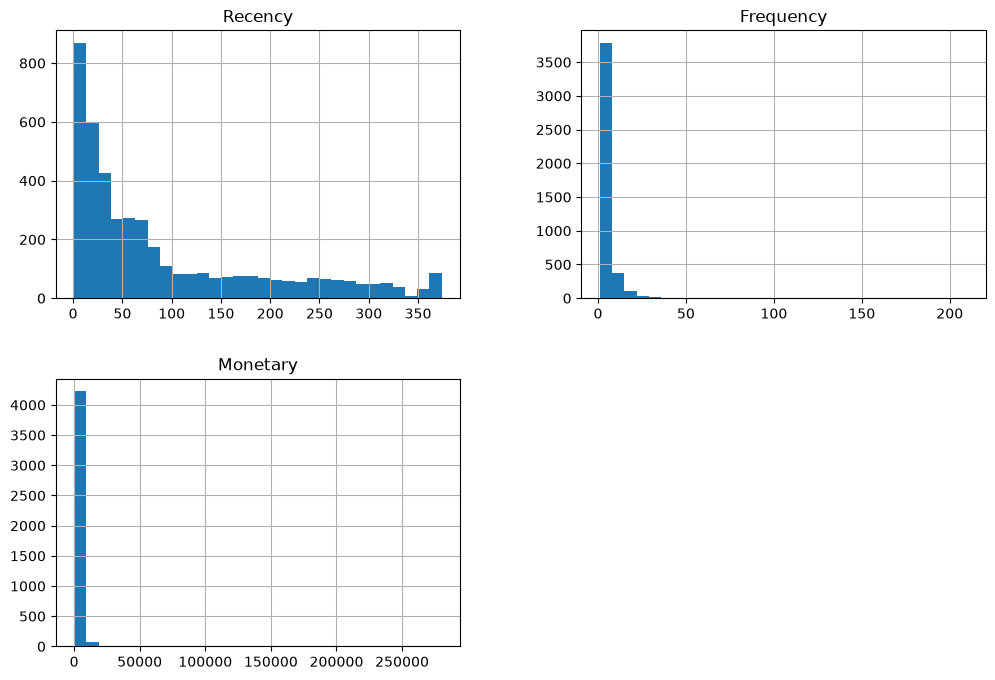

In [148]:
import matplotlib.pyplot as plt


rfm.hist(bins=30, figsize=(12, 8))
plt.xlabel("Jours")
plt.ylabel("clients")
plt.show()

In [ ]:
import seaborn as sns
for col in ["Recency", "Frequency", "Monetary"]:
    sns.boxplot(x=rfm[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [135]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]



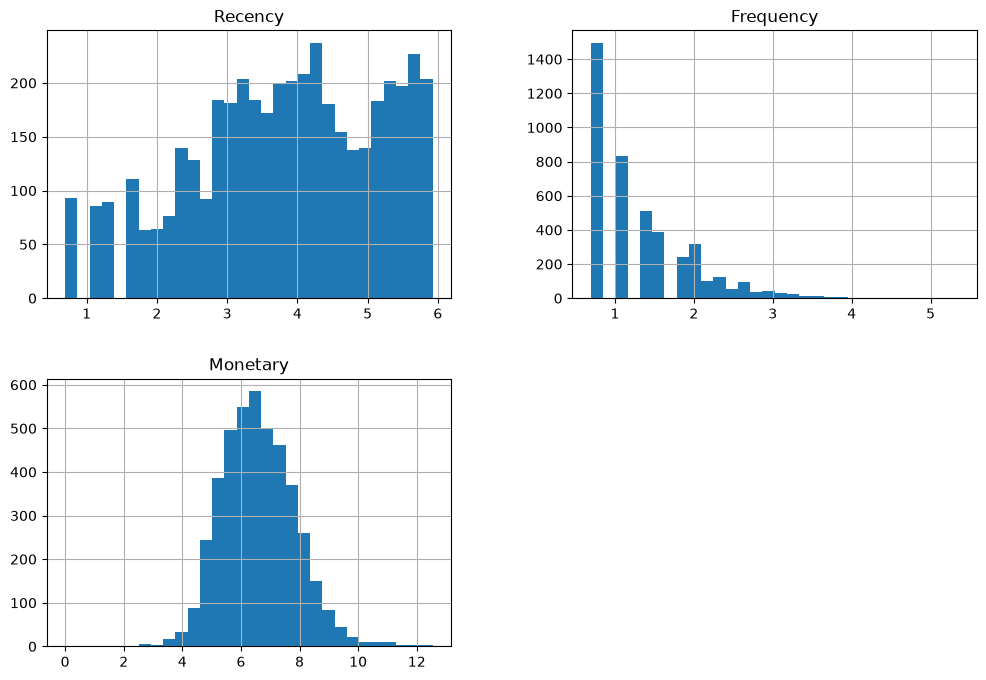

In [149]:
import numpy as np
from sklearn.preprocessing import StandardScaler

rfm_log = np.log1p(rfm)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log)

rfm_log.hist(bins=30, figsize=(12, 8))

plt.show()

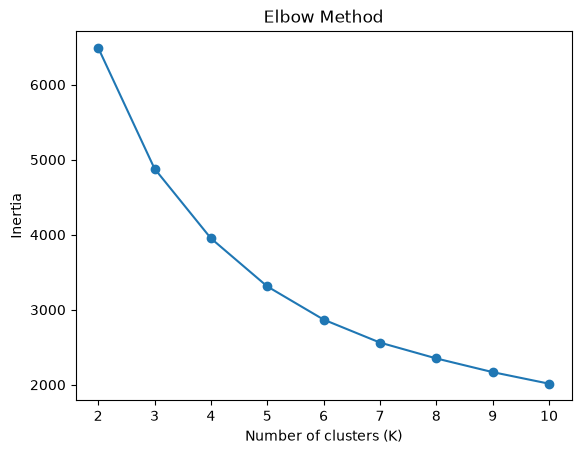

In [146]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Elbow method
inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [152]:
final_k=3
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)
print(rfm)

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        2
12347.0           2          7   4310.00        0
12348.0          75          4   1797.24        2
12349.0          19          1   1757.55        2
12350.0         310          1    334.40        1
...             ...        ...       ...      ...
18280.0         278          1    180.60        1
18281.0         181          1     80.82        1
18282.0           8          2    178.05        2
18283.0           4         16   2094.88        0
18287.0          43          3   1837.28        2

[4339 rows x 4 columns]


4-3-2. Analyser les caractéristiques des clusters

In [ ]:
print(rfm["Cluster"].value_counts().sort_index())

cluster_summary = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean().round(2)

print(cluster_summary)

Cluster
0     734
1    1913
2    1692
Name: count, dtype: int64
         Recency  Frequency  Monetary
Cluster                              
0          15.89      13.70   8101.50
1         164.89       1.36    365.51
2          43.93       3.47   1339.06


In [160]:
rfm["type"] = rfm["Cluster"].map({
    0: "Clients fidèles",
    1: "Clients inactifs",
    2: "Clients occasionnels"
})

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
print(X_pca)


pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm["Cluster"].values

print(pca_df.head())

NameError: name 'X_scaled' is not defined

In [3]:

# plt.figure(figsize=(10, 7))

# for cluster in sorted(pca_df["Cluster"].unique()):
#     data = pca_df[pca_df["Cluster"] == cluster]
rfm_group=pca_df.groupby("Cluster")[["PC1","PC2"]]
for cluster in rfm["Cluster"]:
    plt.scatter(
            pca_df["PC1"],
            pca_df["PC2"],
            label=f"Cluster {cluster}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualisation des clusters avec PCA")
plt.legend()
plt.show()

NameError: name 'pca_df' is not defined